# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_06. Five trials recorded:

- trial_01 = target, h_f 5.349, h_s 7.652 -> 0.0837.
- trial_02 = sim, h_f 5.308, h_s 3.060 -> 0.1249.
- trial_03 = power, h_f 8.658, h_s 4.220 -> 0.1541.
- trial_04 = target, h_f 9.821, h_s 2.920 -> 0.0926.
- trial_05 = target, h_f 3.580, h_s 5.784 -> 0.0818 (current best).

Ranking: target 3.58 (0.0818) < exp6 target 4.0 (0.0803) < target 5.35 (0.0837) < target 9.82 (0.0926)
< sim (0.1249) < power (0.1541). The target rule dominates; its optimum is around h_f ~3.6-4.0; the
five uniform-phase trials are done, so the optimizer now proposes by expected improvement.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 1.0037 | {"bandwidth_rule": "sim", "h_f_scale": 5.059739637749161, "h_s_scale": 11.861894892051133}
 2 | 2.0243 | {"bandwidth_rule": "sim", "h_f_scale": 4.323290222328159, "h_s_scale": 6.607837893399873}
 3 | 3.5160 | {"bandwidth_rule": "target", "h_f_scale": 3.6779179465318403, "h_s_scale": 5.318777143045513}
 4 | 2.6503 | {"bandwidth_rule": "power", "h_f_scale": 3.281831928276722, "h_s_scale": 6.77375556064627}
 5 | 2.4094 | {"bandwidth_rule": "sim", "h_f_scale": 3.0496995054561244, "h_s_scale": 9.354132345045686}
 6 | 1.8190 | {"bandwidth_rule": "sim", "h_f_scale": 10.528046863663635, "h_s_scale": 5.836235332635186}
 7 | 1.1463 | {"bandwidth_rule": "sim", "h_f_scale": 5.598595824722791, "h_s_scale": 6.276934375220883}
 8 | 3.4781 | {"bandwidth_rule": "sim", "h_f_scale": 3.2903593426123927, "h_s_scale": 5.410145217077188}
 9 |      - | {"bandwidth_rule": "power", "h_f_scale": 10.69418113893833, "h_s_scale": 1.7204642298748003}
10

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The uniform phase is over. The candidate table now carries EI values, and the top proposals are
concentrated exactly where the evidence points. Candidate #3 has by far the highest EI (3.516) and is a
`target` configuration at h_f 3.678, h_s 5.319 - essentially the peak region the campaign has found
(target, h_f ~3.6-4.0, h_s ~4-6). It both exploits the best-known rule/coefficient region and, being a
fresh draw, refines it. The next-highest EI candidates (#8 sim 3.29/5.41, #4 power 3.28/6.77) are on the
rules already shown to be clearly inferior (sim 0.1249, power 0.1541), so their EI is discounted by the
evidence against them - and indeed neither reaches the best-observed objective. Candidates #9 and #10
have no EI shown and sit near the caps / high h_f, the region trial_04 showed to be on the wrong side.

Candidate #3 is the clear choice: highest EI, the winning rule, and lands at the target optimum.

I choose candidate 3 (target, h_f_scale 3.678, h_s_scale 5.319).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 3.6779179465318403, 'h_s_scale': 5.318777143045513}
Running  1nW Trans05 ... 

μ 9.39 -> 6.10 | γ 8.5 -> 5.07 | NLL 0.21


Running  1nW Trans20 ... 

μ 17.32 -> 27.67 | γ 8.5 -> 5.45 | NLL 0.57


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.80 | γ 14.1 -> 13.99 | NLL 0.67


Running 3nW Trans100 ... 

μ 175.71 -> 98.66 | γ 14.1 -> 13.82 | NLL 0.65



Total: 7.5 min


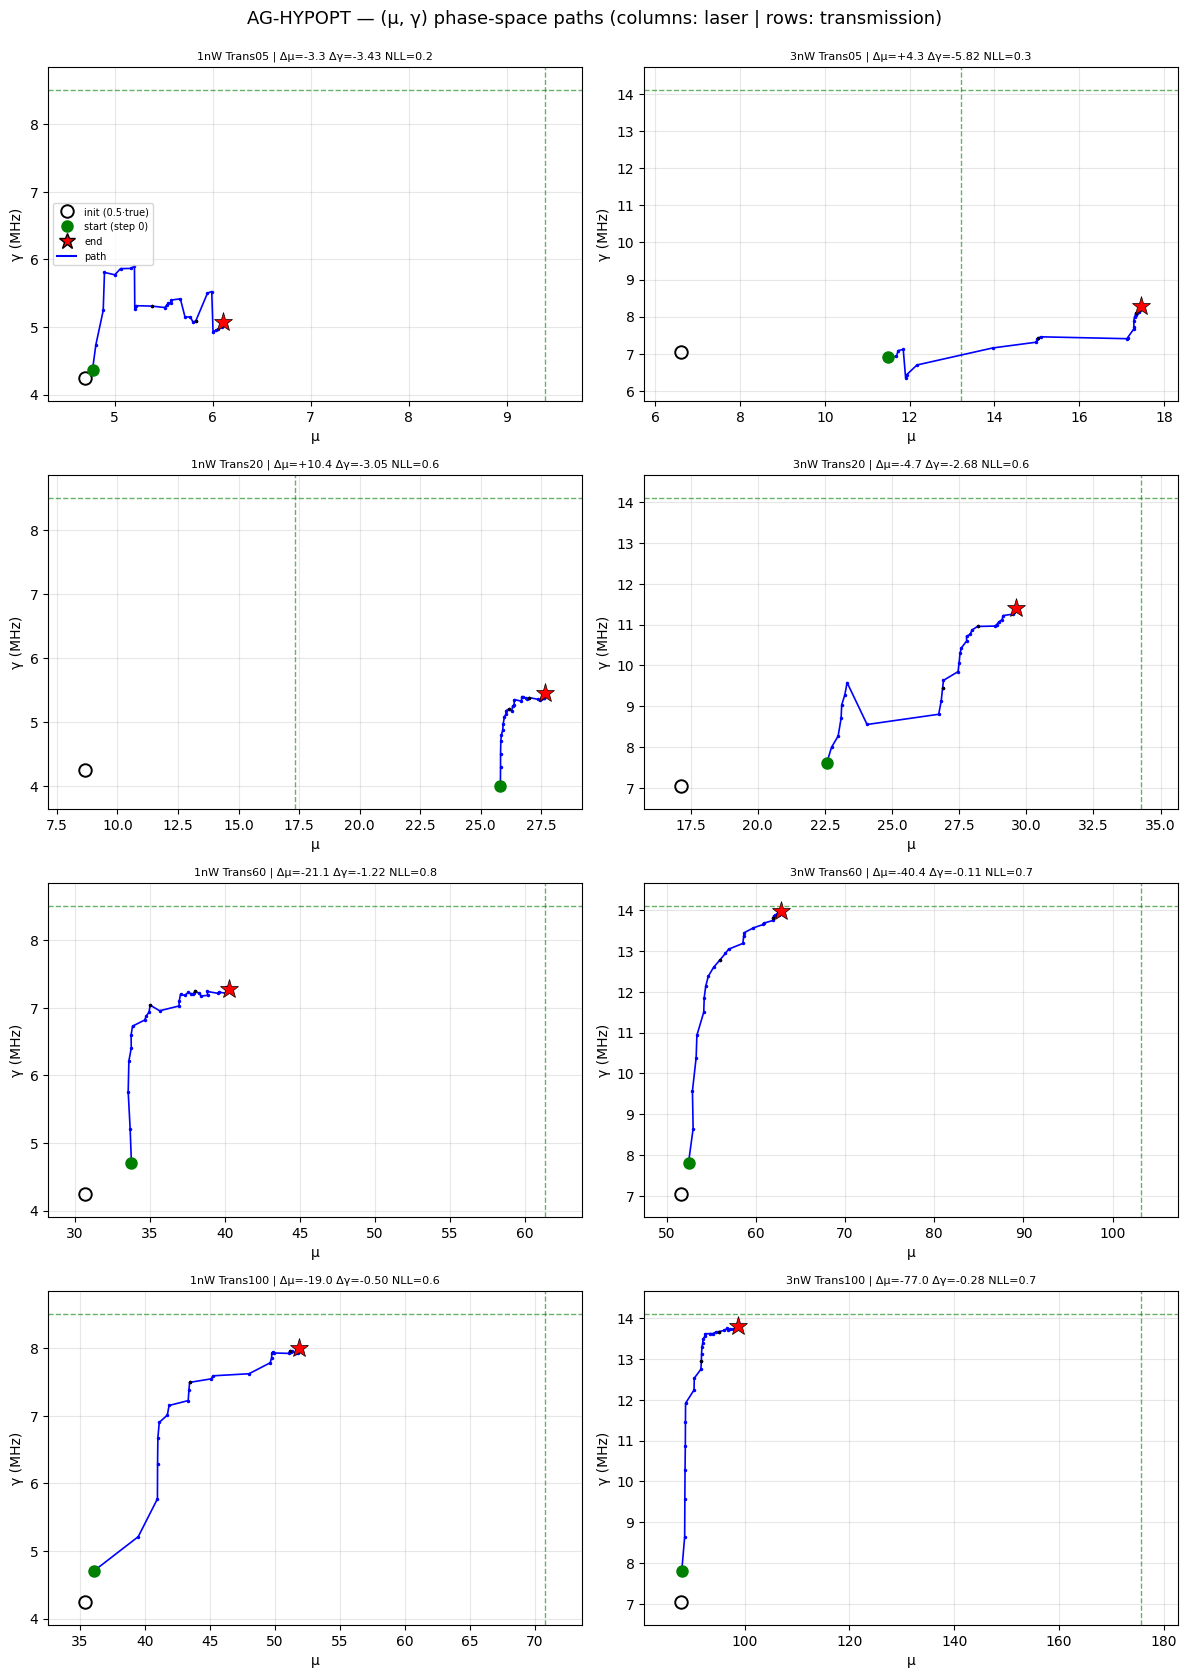

trial finished in 7.5 min
objective = 0.0890 ± 0.0237
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.10   -35.0 |     8.50    5.07   -40.3
1nW Trans20       17.32   27.67   +59.8 |     8.50    5.45   -35.9
1nW Trans60       61.37   40.26   -34.4 |     8.50    7.28   -14.4
1nW Trans100       70.82   51.86   -26.8 |     8.50    8.00    -5.9
3nW Trans05       13.20   17.46   +32.3 |    14.10    8.28   -41.3
3nW Trans20       34.28   29.60   -13.7 |    14.10   11.42   -19.0
3nW Trans60      103.20   62.80   -39.2 |    14.10   13.99    -0.8
3nW Trans100      175.71   98.66   -43.8 |    14.10   13.82    -2.0

weighted objective (T-graded, cap=1.0) = 0.0890 | diverged cells: 0
μ: RMSE 32.656 (rel 37.7%, bias -18.859) | γ: RMSE 2.828 (rel 25.6%, bias -2.137)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

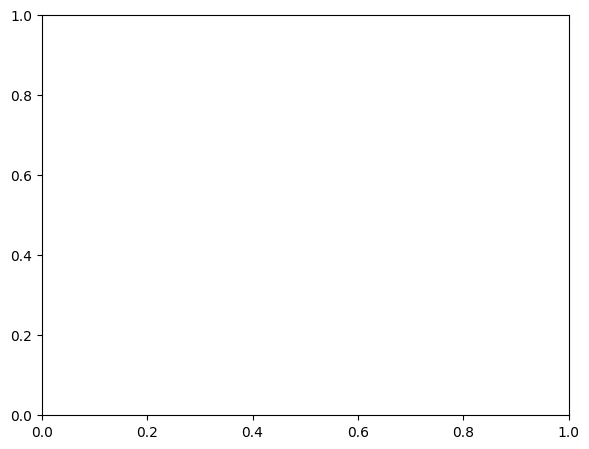

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0890 ± 0.0237, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 3.678, h_s_scale = 5.319 - the top-EI proposal, essentially the same region as the
current-best trial_05 (h_f 3.58).

Per-cell pattern is the campaign's usual one: mu mixed-sign (undershoot at most cells, +59.8 % at 1nW
Trans20 and +32.3 % at 3nW Trans05), gamma underestimated on all 8 cells with the high-T ones nearly
exact (3nW Trans60 -0.8 %, 3nW Trans100 -2.0 %).

Despite being the highest-EI proposal, this scored 0.0890 - very close to but slightly worse than trial_05
(0.0818). The target-rule results now line up as 0.0803 @ h_f 4.0 (exp6), 0.0818 @ 3.58, 0.0837 @ 5.35,
0.0890 @ 3.68 - all with sampling SEs of 0.021-0.024. Given those SEs, the target rule is effectively FLAT
in h_f across roughly [3.5, 5.4]: the spread 0.080-0.089 is comparable to the reported uncertainty, so the
apparent ordering is not resolvable. The only clearly-significant signals remain the rule ordering (target
far below sim/power) and the degradation at large h_f (trial_04 @ 9.82 = 0.0926).

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 6 (target rule, h_f 3.678, h_s 5.319), the highest-EI proposal, scores objective 0.0890 ± 0.0237, within sampling noise of the nearby best (trial_05 0.0818).
**Key insight:** The target rule's objective is essentially flat/noise-limited across h_f ~3.5-5.4 (0.080-0.089, SE ~0.024), so further coefficient tuning of the target rule in that region does not reliably beat exp6's 0.0803.

Notes for Anuar (optional, not acted on): with the target rule flat and the other two rules clearly worse,
the campaign's honest conclusion may be that the frozen exp6 design (target, h_f 4.0) is already at the
bandwidth-rule optimum, and that the remaining objective is dominated by the low-count-cell model gap
(FM#8), not by the bandwidth coefficients.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 6 (target rule, h_f 3.678, h_s 5.319), the highest-EI proposal, scores objective 0.0890 ± 0.0237, within sampling noise of the nearby best (trial_05 0.0818)."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The target rule's objective is essentially flat/noise-limited across h_f ~3.5-5.4 (0.080-0.089, SE ~0.024), so further coefficient tuning of the target rule in that region does not reliably beat exp6's 0.0803."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
